In [1]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=2.2)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
n_states, start_width, delta, measurement_prob,  I, J = 7, 1, 1, 0.8, 1, 1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [3]:
mu, sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100

intensity_matrix_markov = dd._buildK(n_states, mu, sigma)
intensity_matrix_quantum = qd._buildH(n_states, mu, sigma)


In [4]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Upper")

In [5]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
for prior_type in ["Upper", "Centered", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    for t in range(1,51):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[delta]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in range(1,T+1):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[delta]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
        

In [6]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0.5,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [7]:
intensity_matrix_quantum

Array([[[[0.+3.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-2.j, 0.+2.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-2.j, 0.+1.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-2.j, 0.-0.j, 0.-2.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-1.j, 0.-2.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-2.j, 0.-2.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-3.j]]]],      dtype=complex128)

In [8]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov).squeeze())

,0,1,2,3,4,5,6
0,0.213582,0.089562,0.020739,0.003309,0.000403,0.000042,0.000013
1,0.358260,0.275799,0.099490,0.021947,0.003434,0.000442,0.000166
2,0.249035,0.298482,0.258683,0.096554,0.021664,0.003766,0.001717
3,0.120865,0.197687,0.289676,0.257834,0.097551,0.025486,0.014567
4,0.058209,0.094446,0.195141,0.292667,0.269302,0.129952,0.096796
5,0.111987,0.050572,0.103420,0.229544,0.389871,0.483230,0.476110
6,0.125943,0.034727,0.038445,0.098758,0.217832,0.357085,0.410633


In [9]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").reset_index(names="states").assign(states = lambda df: df.states + 1)
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").reset_index(names="states").assign(states = lambda df: df.states + 1)
df_markov_plot

,states,prior,time,value
0,1,Upper,0,0.000013
1,2,Upper,0,0.000166
2,3,Upper,0,0.001717
3,4,Upper,0,0.014567
4,5,Upper,0,0.096796
...,...,...,...,...
1045,3,Lower,49,0.023264
1046,4,Lower,49,0.069838
1047,5,Lower,49,0.209654
1048,6,Lower,49,0.629389


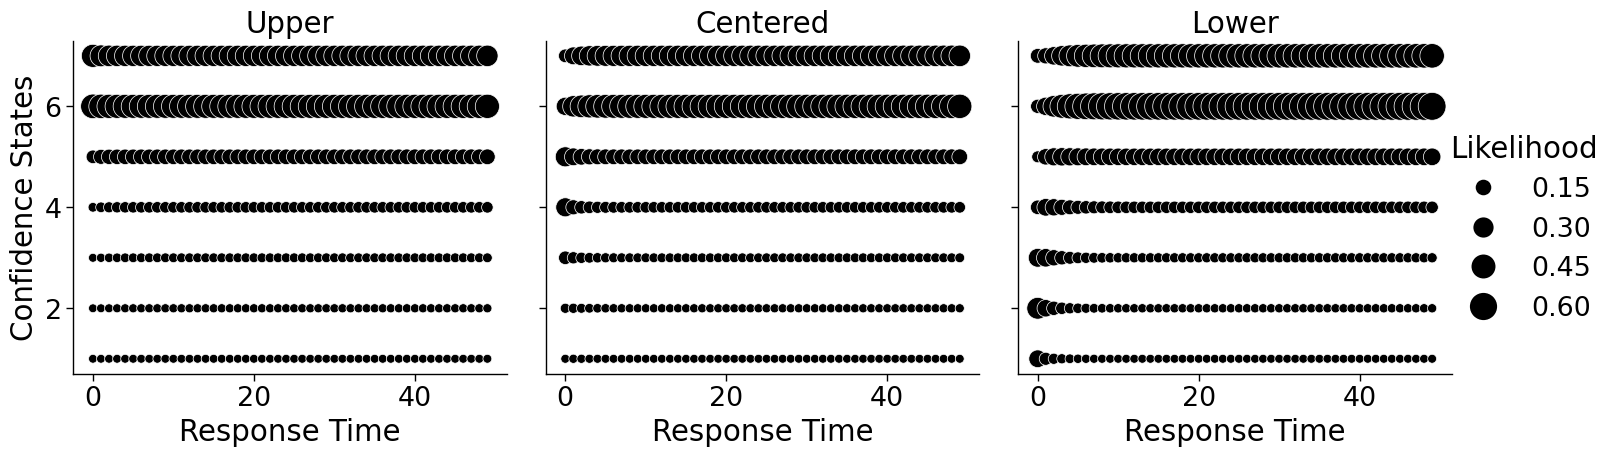

In [10]:
f = sns.relplot(df_markov_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1)
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time")
f.set_ylabels("Confidence States")

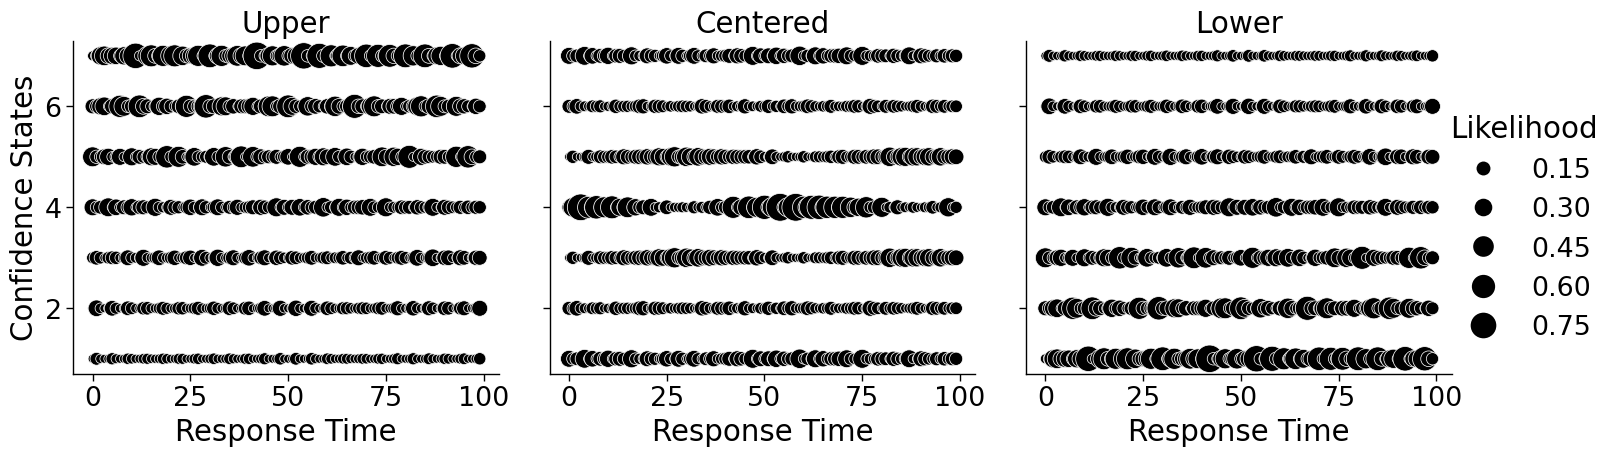

In [11]:
f = sns.relplot(df_quantum_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1)
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time")
f.set_ylabels("Confidence States")

In [12]:
mv = np.arange(0,n_states)
mv

array([0, 1, 2, 3, 4, 5, 6])

In [13]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()

for mu in [npx.asarray([[0.5]]), npx.asarray([[1]]), npx.asarray([[2]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, sigma)
    intensity_matrix_quantum = qd._buildH(n_states, mu, sigma)
    for prior_type in ["Upper", "Centered", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

        phi_markov_arr = []
        phi_quantum_arr = []
        for t in range(1,51):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in range(1,T+1):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=np.asarray(mu[0,0]))])
        df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=np.asarray(mu[0,0]))])
        

In [14]:
df_markov_plot = df_markov.melt(id_vars=["prior", "mu"], var_name="time")
df_quantum_plot = df_quantum.melt(id_vars=["prior", "mu"], var_name="time")
df_quantum_plot

,prior,mu,time,value
0,Upper,0.5,0,3.583066
1,Centered,0.5,0,3.000000
2,Lower,0.5,0,2.416934
3,Upper,1.0,0,3.756491
4,Centered,1.0,0,3.000000
...,...,...,...,...
895,Centered,1.0,99,3.000000
896,Lower,1.0,99,3.263472
897,Upper,2.0,99,5.443661
898,Centered,2.0,99,3.000000


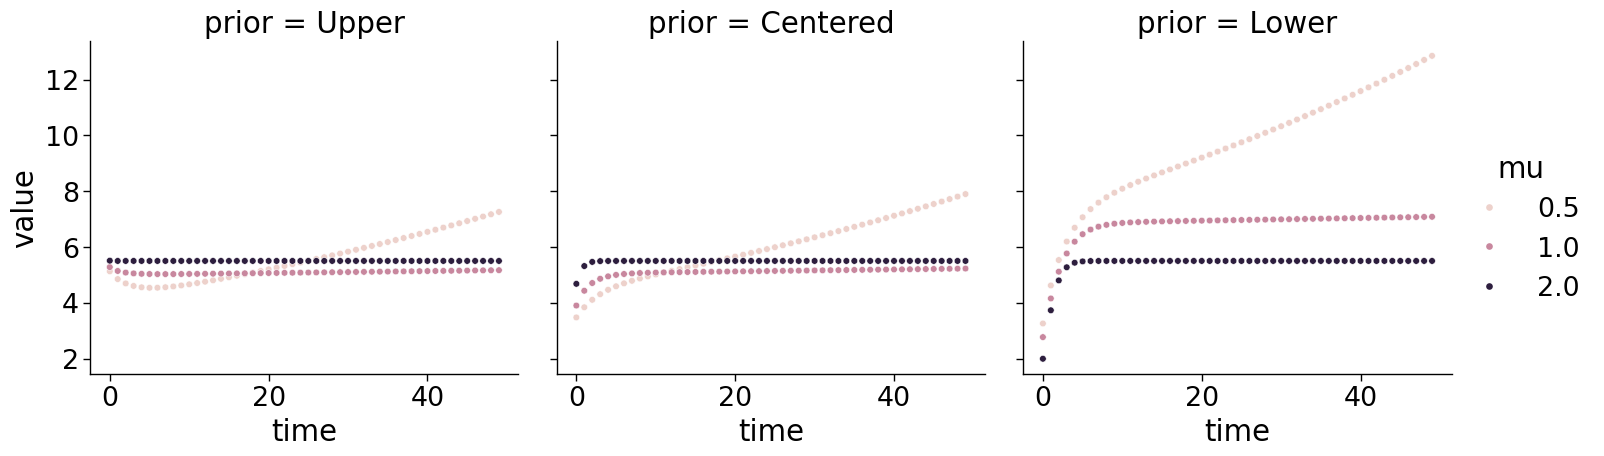

In [15]:
f = sns.relplot(df_markov_plot,
x="time", y="value", col="prior", hue="mu")